## 1. Offer Response by Product Group

This analysis visualizes the difference in observed offer-response rates between customers with one product and customers with two or more products.

The objective is to present the strongest product-related finding from the SQL analysis in a simple business-friendly chart.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import mysql.connector
from getpass import getpass

conn = mysql.connector.connect(
    host='localhost',
    user=input('MySQL username: '),
    password=getpass('MySQL password: '),
    database='banking_analysis'
)

print("Connected successfully")

MySQL username:  root
MySQL password:  ········


Connected successfully


In [48]:
query = """
SELECT
    num_products,
    responded_to_offer_clean,
    utilization_clean,
    late_payments_last_year,
    churned_clean
FROM accounts;
"""

account_sql = pd.read_sql(query, conn)

/var/folders/mt/n8_vz8jx4p5dxpftk4rdzlw40000gp/T/ipykernel_34400/34207818.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  account_sql = pd.read_sql(query, conn)


In [8]:
product_group = np.where(
        account_sql['num_products'] == 1,
        '1 Product',
        '2+ Products'
    )


In [9]:
product_group

array(['1 Product', '2+ Products', '2+ Products', ..., '1 Product',
       '2+ Products', '1 Product'], shape=(10996,), dtype='<U11')

In [11]:
response_rate = (
    pd.DataFrame({'product_group': product_group,
                   'responded': account_sql['responded_to_offer_clean']
                 })
)

In [28]:
df = round(response_rate.groupby('product_group')['responded'].mean().mul(100),2).reset_index(name='response_rates')

## 1.1 Calculate Offer Response Rate

Offer response is coded as 0 for customers who did not respond and 1 for customers who responded.

The response rate is calculated separately for each product group. Since the response variable contains 0 and 1 values, the mean of the response variable represents the proportion of customers who responded.

The proportion is multiplied by 100 to express the result as a percentage.

## 1.2 Visualize Offer Response by Product Group

The response rates are visualized using a bar chart to make the difference between single-product and multi-product customers easier to interpret.

In [21]:
import matplotlib.pyplot as plt

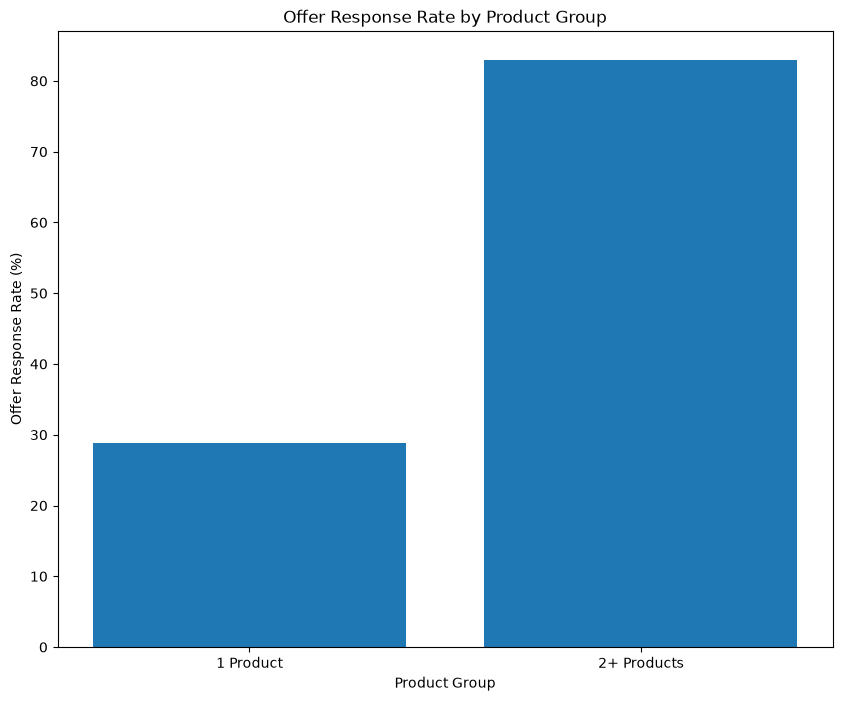

In [42]:
plt.figure(figsize=(10,8))

plt.bar(
    df['product_group'],
    df['response_rates']
)

plt.xlabel('Product Group')
plt.ylabel('Offer Response Rate (%)')
plt.title('Offer Response Rate by Product Group')

plt.savefig(
    '/Users/gulu/Desktop/DA/Portfolio_Projects/Charts/Offer Response Rate by Product Group.png',
    bbox_inches='tight'
)

plt.show()

## 2. Offer Response by Credit Utilization

This chart visualizes the observed offer-response rate across different levels of credit utilization.

The objective is to show whether offer response varies as customers use a larger proportion of their available credit.

In [33]:
utilization_group = pd.cut(
    account_sql['utilization_clean'],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=['0-25%', '25-50%', '50-75%', '75-100%'],
    include_lowest=True
)

In [34]:
utilization_response = (
    account_sql
    .groupby(utilization_group, observed=True)['responded_to_offer_clean']
    .mean()
    .mul(100)
    .round(2)
)

utilization_response

utilization_clean
0-25%      66.99
25-50%     67.57
50-75%     35.34
75-100%    25.64
Name: responded_to_offer_clean, dtype: float64

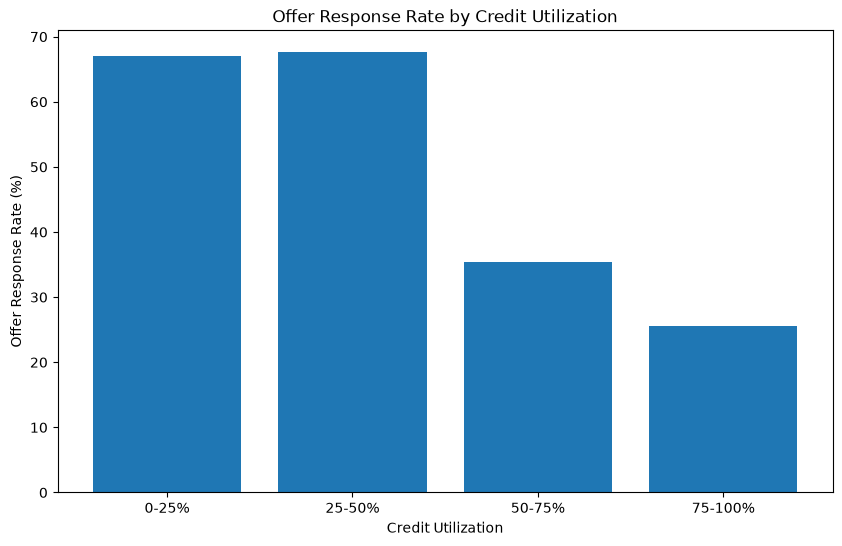

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    utilization_response.index.astype(str),
    utilization_response.values
)

plt.xlabel('Credit Utilization')
plt.ylabel('Offer Response Rate (%)')
plt.title('Offer Response Rate by Credit Utilization')
plt.savefig(
    '/Users/gulu/Desktop/DA/Portfolio_Projects/Charts/Offer Response Rate by Credit Utilization',
    bbox_inches='tight'
)

plt.show()

## 3. Churn Rate by Late-Payment Group

This chart visualizes the observed churn rate across customer groups based on the number of late payments recorded during the last year.

The objective is to make the relationship between late-payment behaviour and observed churn easier to interpret.

In [46]:
late_payment_group = pd.cut(
    account_sql['late_payments_last_year'],
    bins=[-1, 2, 5],
    labels=['0-2 Late Payments', '3+ Late Payments']
)

In [49]:
churn_rates = (
    account_sql
    .groupby(late_payment_group, observed=True)['churned_clean']
    .mean()
    .mul(100)
    .round(2)
)

churn_rates

late_payments_last_year
0-2 Late Payments    12.79
3+ Late Payments     34.31
Name: churned_clean, dtype: float64

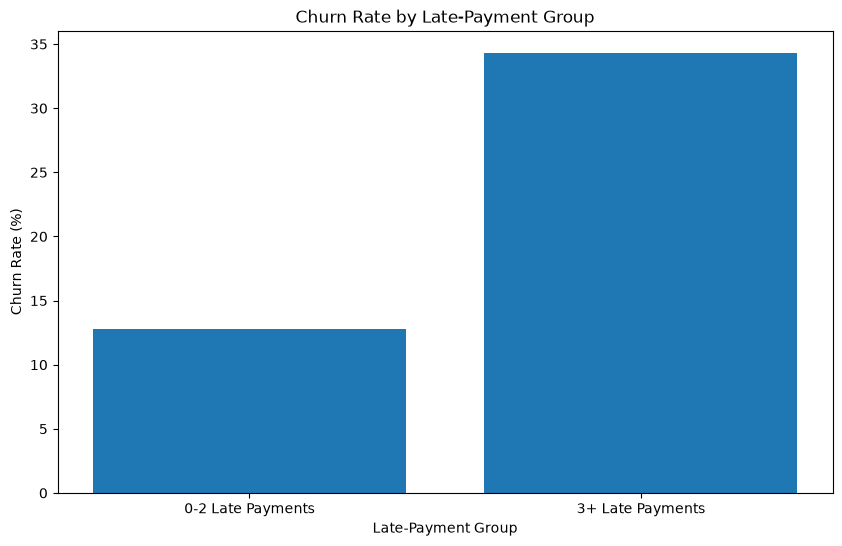

In [50]:
plt.figure(figsize=(10, 6))

plt.bar(
    churn_rates.index.astype(str),
    churn_rates.values
)

plt.xlabel('Late-Payment Group')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Late-Payment Group')

plt.savefig(
    '/Users/gulu/Desktop/DA/Portfolio_Projects/Charts/Churn Rate by Late Payment Group.png',
    bbox_inches='tight'
)

plt.show()

## 4. Churn Rate by Offer Response

This chart compares the observed churn rate between customers who responded to the marketing offer and customers who did not respond.

The objective is to visualize the difference in observed churn between the two offer-response groups.

In [51]:
churn_by_response = (
    account_sql
    .groupby('responded_to_offer_clean')['churned_clean']
    .mean()
    .mul(100)
    .round(2)
)

churn_by_response

responded_to_offer_clean
0    25.55
1     7.76
Name: churned_clean, dtype: float64

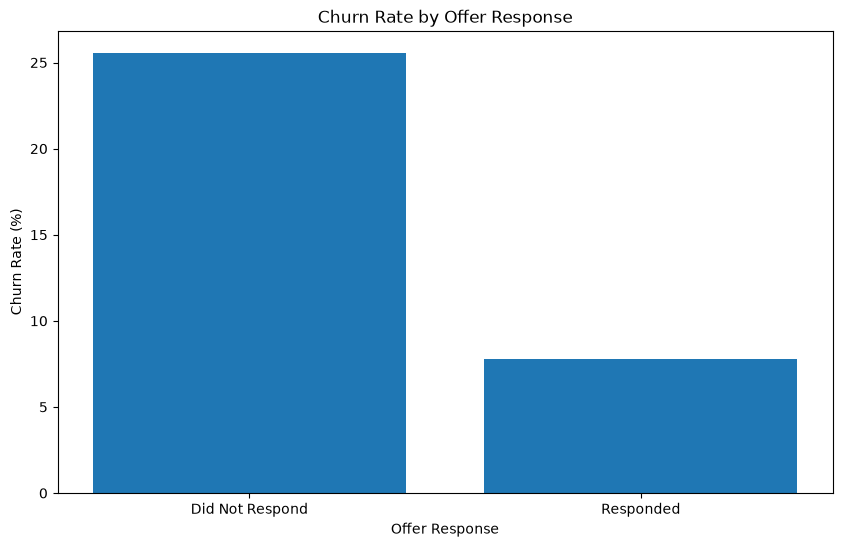

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    ['Did Not Respond', 'Responded'],
    churn_by_response.values
)

plt.xlabel('Offer Response')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Offer Response')

plt.savefig(
    '/Users/gulu/Desktop/DA/Portfolio_Projects/Charts/Churn Rate by Offer Response.png',
    bbox_inches='tight'
)

plt.show()

## 5. Visual Analysis Summary

The visual analysis highlights four key patterns identified during the SQL analysis.

### Product Relationship

Customers with two or more products show a substantially higher observed offer-response rate than single-product customers.

### Credit Utilization

Offer-response rates remain relatively high below 50% utilization but decline substantially at higher utilization levels.

### Late Payments

Observed churn is substantially higher among customers with 3 or more late payments than among customers with 0 to 2 late payments.

### Offer Response and Churn

Customers who did not respond to the offer have a substantially higher observed churn rate than customers who responded.

These charts summarize observed relationships in the dataset and do not establish causation.